In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../data/processed/india_aq_clean.csv' , parse_dates = ['datetime' , 'datetime_local'])

##### filtering one pollutant (PM25)

In [8]:
pm25 = df[df['parameter'] == 'pm25'].copy()
print(f"Shape of PM2.5 data : {pm25.shape[0]}")
print(pm25.head())

Shape of PM2.5 data : 13790
      location_id         location  sensor_id parameter  units  value  \
2000           17  R K Puram Delhi   12234787      pm25  µg/m³  123.0   
2001           17  R K Puram Delhi   12234787      pm25  µg/m³   97.0   
2002           17  R K Puram Delhi   12234787      pm25  µg/m³   97.0   
2003           17  R K Puram Delhi   12234787      pm25  µg/m³   97.0   
2004           17  R K Puram Delhi   12234787      pm25  µg/m³   97.0   

                      datetime            datetime_local  
2000 2025-02-18 20:00:00+00:00 2025-02-19 01:30:00+05:30  
2001 2025-02-18 20:15:00+00:00 2025-02-19 01:45:00+05:30  
2002 2025-02-18 20:30:00+00:00 2025-02-19 02:00:00+05:30  
2003 2025-02-18 20:45:00+00:00 2025-02-19 02:15:00+05:30  
2004 2025-02-18 21:00:00+00:00 2025-02-19 02:30:00+05:30  


##### resampling part but it requires datetime to be index thats the key concept

In [14]:
pm25 = pm25.set_index('datetime_local')
pm25.head()


,location_id,location,sensor_id,parameter,units,value
datetime_local,,,,,,
2025-02-19 01:30:00+05:30,17,R K Puram Delhi,12234787,pm25,µg/m³,123.0
2025-02-19 01:45:00+05:30,17,R K Puram Delhi,12234787,pm25,µg/m³,97.0
2025-02-19 02:00:00+05:30,17,R K Puram Delhi,12234787,pm25,µg/m³,97.0
2025-02-19 02:15:00+05:30,17,R K Puram Delhi,12234787,pm25,µg/m³,97.0
2025-02-19 02:30:00+05:30,17,R K Puram Delhi,12234787,pm25,µg/m³,97.0


##### resample to dialy avg PM2.5

In [15]:
daily_avg = pm25['value'].resample('D').mean()
print(daily_avg.head())

datetime_local
2016-02-05 00:00:00+05:30    242.555556
2016-02-06 00:00:00+05:30    224.886364
2016-02-07 00:00:00+05:30    180.122302
2016-02-08 00:00:00+05:30    136.360000
2016-02-09 00:00:00+05:30    198.536765
Freq: D, Name: value, dtype: float64


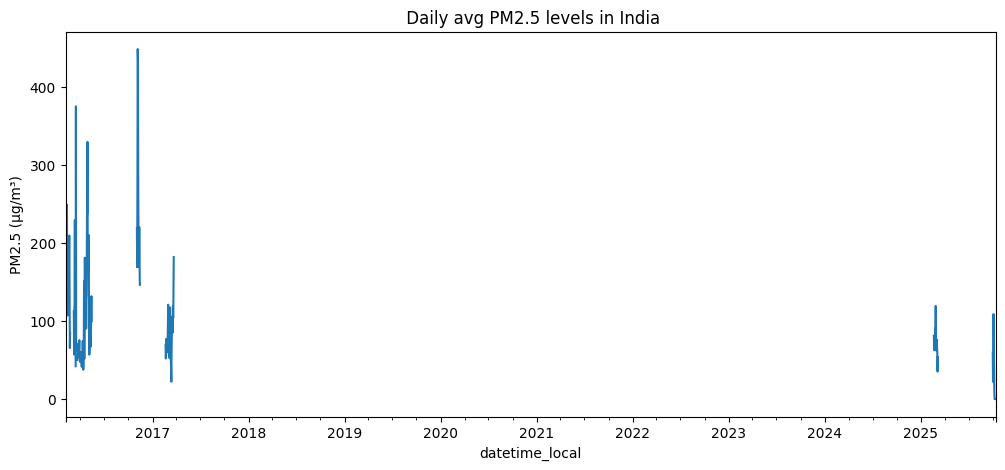

In [18]:
daily_avg.plot(figsize = (12 , 5), title = " Daily avg PM2.5 levels in India")
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

##### here's a massive gap from 2017 to 2025. Data only exists in 2016-2017 and 2025. That's because our 10 stations only uploaded data during those periods. This is a real-world problem — data availability is inconsistent.

In [19]:
pm25_by_station = df[df['parameter'] == 'pm25'].groupby('location')['datetime_local'].agg(['min' , 'max' , 'count'])
print(pm25_by_station)

                                           min                       max  \
location                                                                   
Alandur Chennai      2017-02-19 01:15:00+05:30 2017-03-14 00:15:00+05:30   
Anand Vihar Delhi    2016-02-05 19:30:00+05:30 2025-03-06 18:15:00+05:30   
Collectorate Gaya    2016-03-21 21:05:00+05:30 2016-04-16 13:20:00+05:30   
Income Tax Delhi     2016-11-02 23:00:00+05:30 2016-11-14 07:15:00+05:30   
Lalbagh Mumbai       2017-02-17 09:15:00+05:30 2017-03-22 08:30:00+05:30   
Punjabi Bagh Delhi   2016-02-05 20:10:00+05:30 2025-03-01 22:15:00+05:30   
R K Puram Delhi      2016-02-05 20:10:00+05:30 2025-03-03 17:15:00+05:30   
Vikas Sadan Gurugram 2016-03-25 12:30:00+05:30 2025-10-12 22:45:00+05:30   
Zoo Park Hyderabad   2016-03-21 23:45:00+05:30 2025-03-02 05:00:00+05:30   

                      count  
location                     
Alandur Chennai         989  
Anand Vihar Delhi      1981  
Collectorate Gaya       999  
Income Tax De

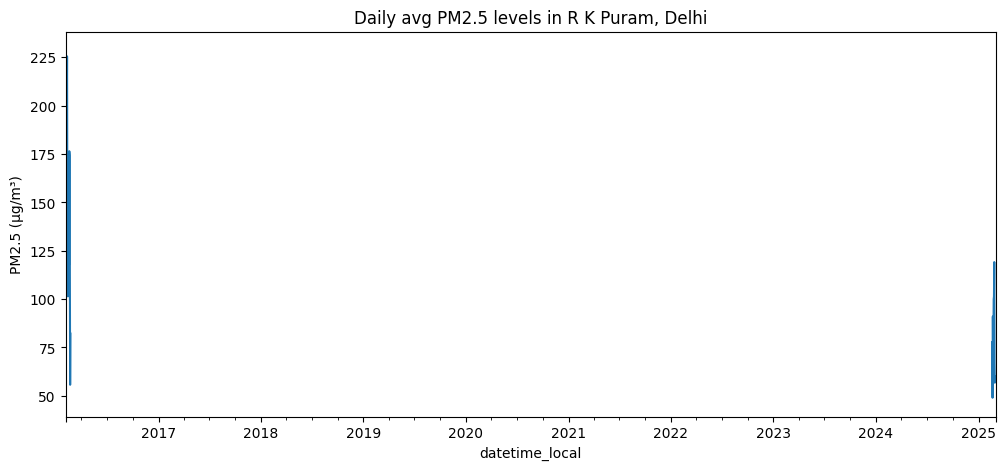

In [20]:
pm25_delhi = pm25[pm25['location'] == 'R K Puram Delhi']['value']
pm25_delhi.resample('D').mean().plot(figsize = (12 , 5) , title = "Daily avg PM2.5 levels in R K Puram, Delhi")
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

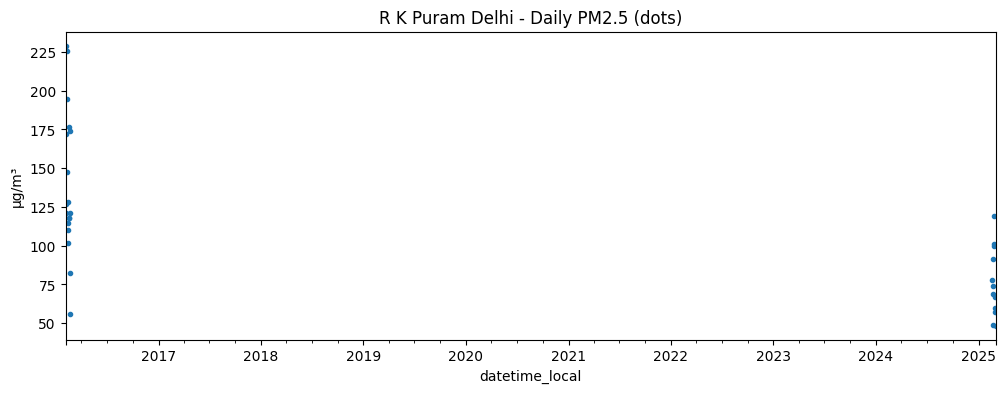

In [21]:
delhi_pm25 = pm25[pm25["location"] == "R K Puram Delhi"]["value"]
delhi_daily = delhi_pm25.resample("D").mean()
delhi_daily.plot(style=".", figsize=(12, 4), title="R K Puram Delhi - Daily PM2.5 (dots)")
plt.ylabel("µg/m³")
plt.show()

In [22]:
pm25["value"].groupby(pm25.index.year).count()

datetime_local
2016    6837
2017    1989
2025    4964
Name: value, dtype: int64

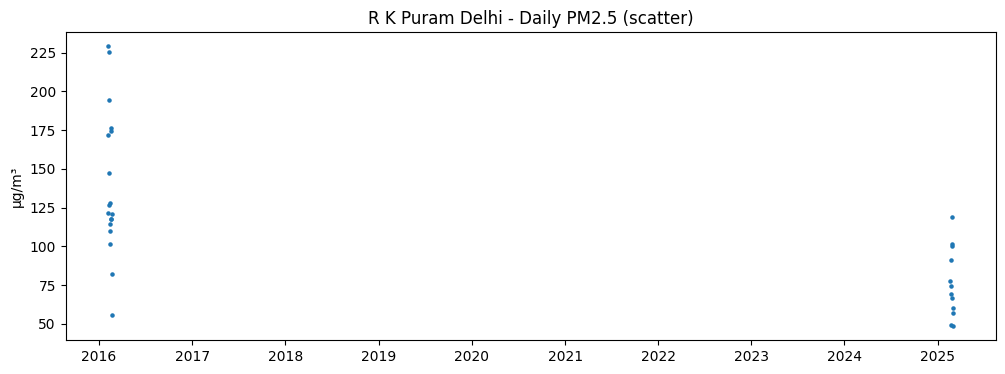

In [23]:
data = delhi_daily.dropna()
plt.figure(figsize= (12 , 4))
plt.scatter(data.index , data.values , s = 5)
plt.title("R K Puram Delhi - Daily PM2.5 (scatter)")
plt.ylabel("µg/m³")
plt.show()

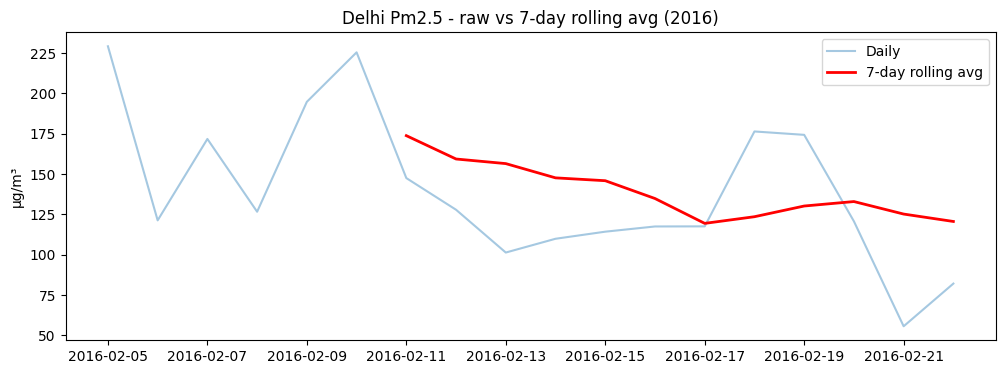

In [25]:
delhi_2016 = pm25[(pm25['location'] == 'R K Puram Delhi') & (pm25.index.year == 2016)]['value']
daily = delhi_2016.resample('D').mean().dropna()

rolling_7 = daily.rolling(7).mean()

plt.figure(figsize = (12 , 4))
plt.plot(daily.index , daily.values , alpha = 0.4 , label = 'Daily')
plt.plot(rolling_7.index , rolling_7.values , color = 'red' , linewidth = 2 , label = '7-day rolling avg')
plt.title("Delhi Pm2.5 - raw vs 7-day rolling avg (2016)")
plt.ylabel("µg/m³")
plt.legend()
plt.show()


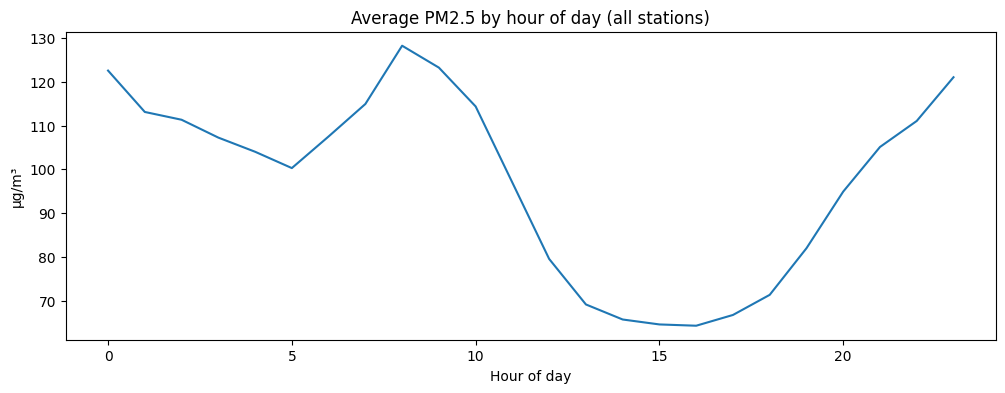

In [26]:
hourly = pm25['value'].groupby(pm25.index.hour).mean()

hourly.plot(figsize  = (12 , 4 ) , title = "Average PM2.5 by hour of day (all stations)")
plt.xlabel("Hour of day")
plt.ylabel("µg/m³")
plt.show()

##### Average PM2.5 acorss station


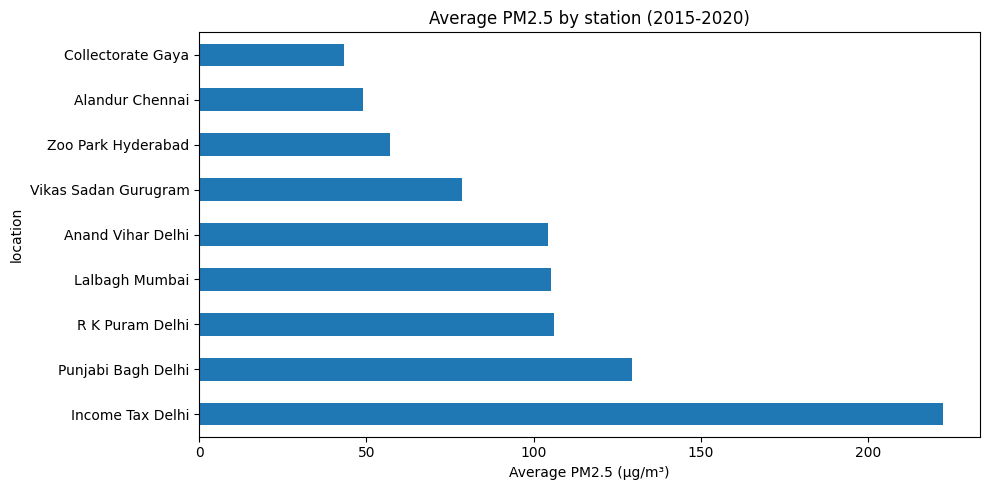

In [29]:
station_pm25_avg = df[df['parameter'] == 'pm25'].groupby('location')['value'].mean().sort_values(ascending = False)

station_pm25_avg.plot.barh(figsize = (10 , 5) , title = "Average PM2.5 by station (2015-2020)")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


##### Monthly / seasonal pattern

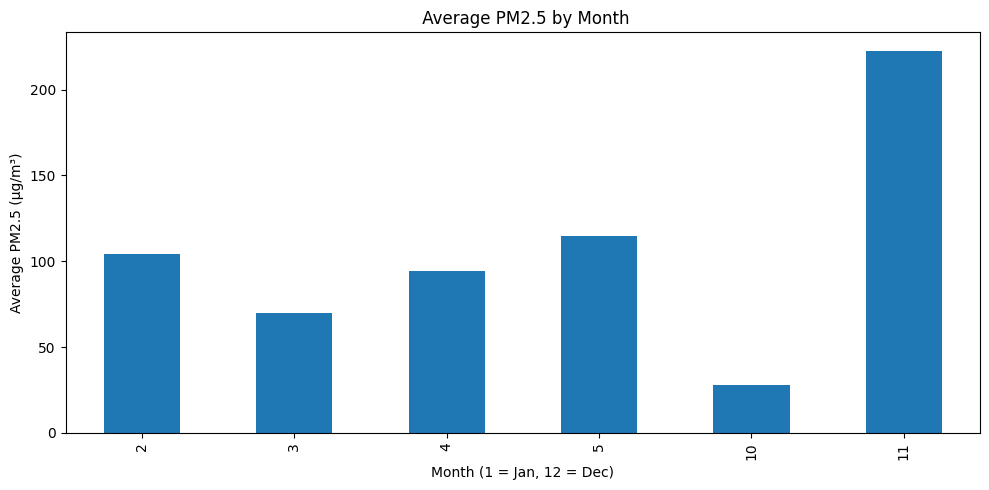

In [33]:
monthly = df[df['parameter'] == 'pm25'].copy()
monthly['month'] = monthly['datetime_local'].dt.month

monthly.groupby('month')['value'].mean().plot.bar(figsize = (10 , 5) , title = " Average PM2.5 by Month")
plt.xlabel("Month (1 = Jan, 12 = Dec)")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

##### co-relation heatamp 

##### Does high PM2.5 mean high NO2?" — you need to pivot the data first.

Right now your data is in long format (one row per reading)

In [34]:
import seaborn as sns

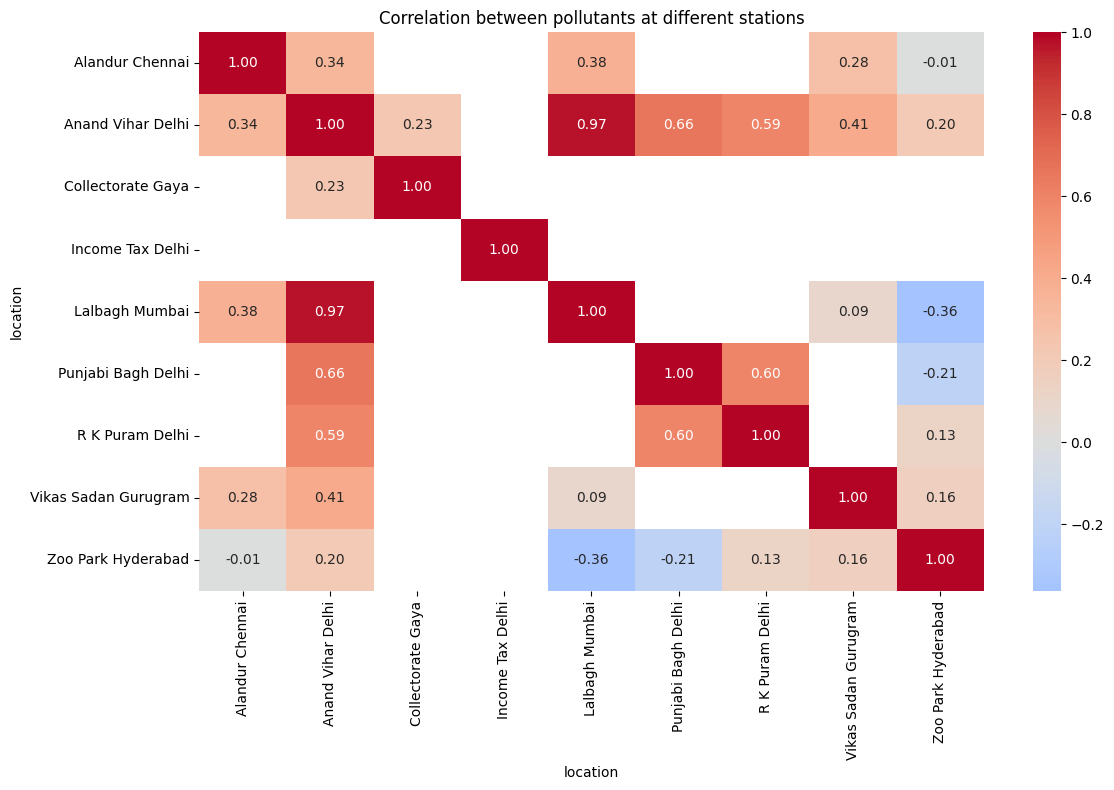

In [36]:
pivot = df.pivot_table(index = 'datetime_local' , columns = 'location' , values = 'value')

#c correlation matrix
corr = pivot.corr()
# heatmap
plt.figure(figsize = (12 , 8))
sns.heatmap(corr , annot = True ,fmt = '.2f' , cmap = 'coolwarm' , center = 0)
plt.title("Correlation between pollutants at different stations")
plt.tight_layout()
plt.show()

##### Sigma Anomaly Detection


In [37]:
pm25_vals = df[df['parameter'] == 'pm25']['value']
mean = pm25_vals.mean()
std = pm25_vals.std()

upper = mean + 3 * std
lower = mean - 3 * std

# threshold = mean + 3 * std
# outliers = pm25_vals[pm25_vals > threshold]

anomalies = pm25_vals[(pm25_vals > upper) | (pm25_vals < lower)]
print(f"Mean: {mean:.2f}, Std: {std:.2f}")
print(f"3σ bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Anomalies found: {len(anomalies)}")

Mean: 96.82, Std: 78.55
3σ bounds: [-138.84, 332.48]
Anomalies found: 331
